# Introduction

In [71]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mikhail1681/walmart-sales/Walmart_Sales.csv


# Imports

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

# Dataset Overview

In [73]:
df = pd.read_csv('/kaggle/input/datasets/mikhail1681/walmart-sales/Walmart_Sales.csv')

df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [75]:
df.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [76]:
df.duplicated().sum()

np.int64(0)

In [77]:
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


# Data Exploration and Visualization

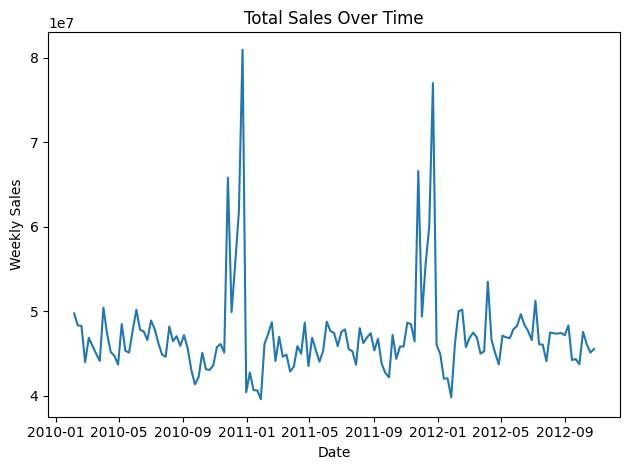

In [78]:
#Total Sales Over Time
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
time_sales = df.groupby(['Date'])['Weekly_Sales'].sum().reset_index().set_index('Date')
plt.plot(time_sales.index, time_sales.values)
plt.title('Total Sales Over Time')
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.tight_layout()
plt.show()

There are spikes in weekly sales during November and December. It is likely connected to the holiday season. However, sales drop dramatically at the beginning of the new year. The reasons for this slump can range from consumers having less disposable money after the holidays to stores heavily discounting products to remove excess inventory. 

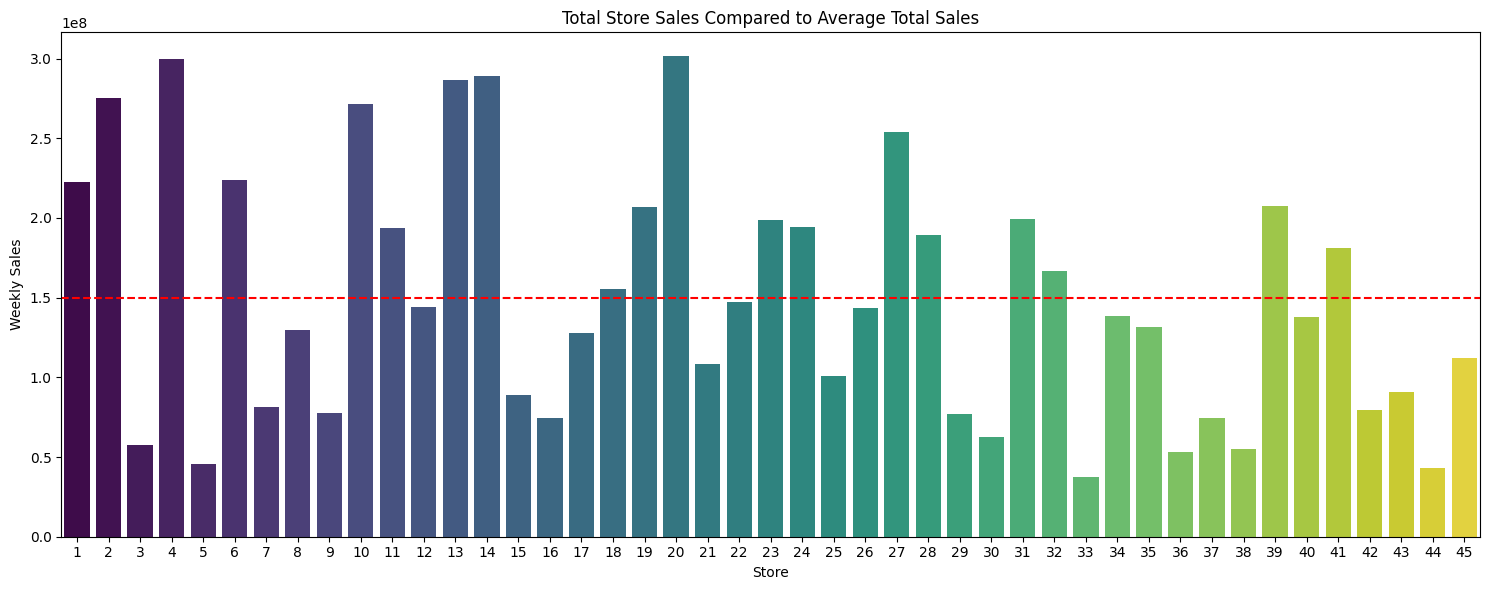

In [79]:
#Total sales by each store
store_sales = df.groupby("Store")["Weekly_Sales"].sum().reset_index()

#Average total sales
avg_sales = store_sales["Weekly_Sales"].mean()

#Graphing total sales
plt.figure(figsize=(15,6))
sns.barplot(data=store_sales, x=store_sales["Store"], y=store_sales["Weekly_Sales"], hue=store_sales["Store"], palette='viridis', legend=False)

#Adding an average line
plt.axhline(y=avg_sales, color="red", linestyle="--", linewidth=1.5) 

plt.title("Total Store Sales Compared to Average Total Sales")
plt.xlabel("Store")
plt.ylabel("Weekly Sales")
plt.tight_layout()
plt.show()

Out of the forty-five stores, nineteen have above-average sales, and the other twenty-six fall below average. 

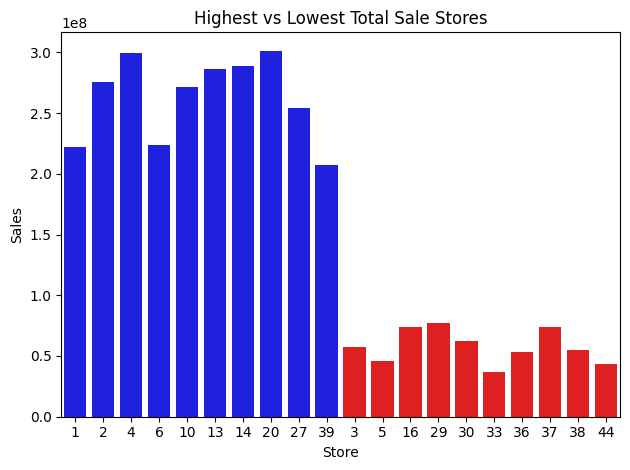

In [80]:
#Highest and lowest total sale stores
store_sales = df.groupby("Store")["Weekly_Sales"].sum().sort_values(ascending=False).head(10)

sns.barplot(x=store_sales.index, y=store_sales.values, color='blue')
store_sales = df.groupby("Store")["Weekly_Sales"].sum().sort_values(ascending=True).head(10)
sns.barplot(x=store_sales.index, y=store_sales.values, color='red')
plt.title('Highest vs Lowest Total Sale Stores')
plt.xlabel('Store')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

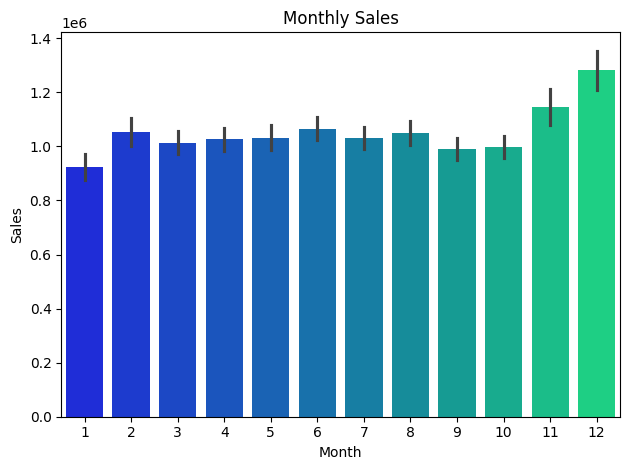

In [81]:
#Converting date to month
df['month'] = df['Date'].dt.month
month_sales = df.groupby('month')['Weekly_Sales'].sum().reset_index()

sns.barplot(data=df, x='month', y='Weekly_Sales', palette='winter')
plt.title('Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

December and November have the most sales, but February and June are not far behind.

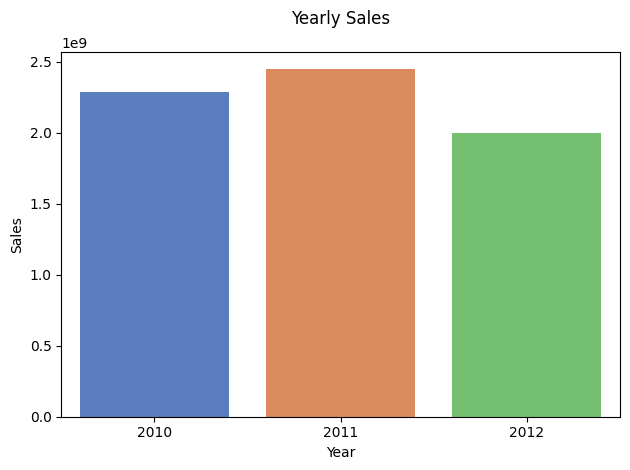

In [82]:
#Converting date to year 
df['year'] = df['Date'].dt.year

year_sales = df.groupby('year')['Weekly_Sales'].sum().reset_index()
sns.barplot(x=year_sales['year'],y=year_sales['Weekly_Sales'],palette="muted")
plt.title("Yearly Sales", pad=20)
plt.ylabel("Sales")
plt.xlabel("Year")
plt.tight_layout()
plt.show()

2011 had the most sales followed by 2010 and 2012.

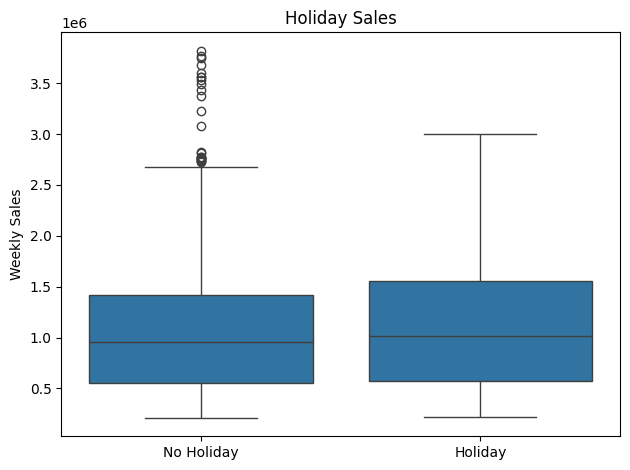

In [83]:
#Holiday Sales
sns.boxplot(data=df,x='Holiday_Flag',y="Weekly_Sales")
plt.title("Holiday Sales")
plt.xlabel("")
plt.ylabel("Weekly Sales")
plt.xticks([0, 1], ["No Holiday", "Holiday"])
plt.tight_layout()
plt.show()

Holiday weeks have slightly higher average sales and strong stability, which is good for predictability. Non-holiday weeks are inconsistent and prone to outliers, which can be caused by various factors such as regional promotions, consumer trends, customer feedback, and more. 

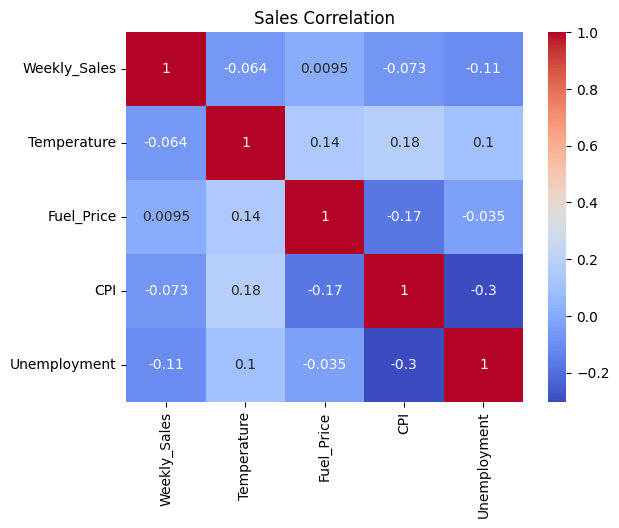

In [84]:
#Mapping Correlations
cols = ["Weekly_Sales", "Temperature", "Fuel_Price", "CPI", "Unemployment"]
corr = df[cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Sales Correlation")
plt.show()

There are no strong positive or negative correlations concerning temperature, fuel prices, the consumer price index, and unemployment rates with weekly sales. None of these correlations have a significant impact on sales.